# 02 — Model Analysis: Results, Ablations, Error Analysis

Loads logged experiments from `results/experiments/`, compares Approach A
(classifier) vs. Approach B (autoencoder), generates ROC/PR curves,
confusion matrices, anomaly score distributions, and walks through
misclassified examples for error analysis.

**Prerequisite:** at least one run each of `src.training.train_classifier`
and `src.training.train_autoencoder` (see `scripts/train.sh`).

In [2]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from src.training.train_classifier import build_dataloaders as build_classifier_dataloaders, evaluate
from src.training.train_autoencoder import build_dataloaders as build_ae_dataloaders, compute_scores
from src.evaluation.experiment_log import load_all_experiments
from src.evaluation.metrics import roc_curve_points, pr_curve_points
from src.utils import get_device
from src.data.dataset import build_transforms
from src.visualization.gradcam import generate_gradcam_overlay

records=load_all_experiments('../results/experiments')
print(f'Loaded {len(records)} experiment records')
for r in records:
    print(f"- {r['experiment_name']} @ {r['timestamp_utc']}")

Loaded 4 experiment records
- classifier_resnet18_bottle_v1 @ 20260913T212729Z
- conv_autoencoder_bottle_v1 @ 20260913T214727Z
- baseline_mean_image_distance @ 20260914T001928Z
- baseline_hog_color_logreg @ 20260914T001929Z


## 1. Summary table: all runs, key metrics side by side

In [3]:
rows=[]
for r in records:
    test=r['metrics'].get('test', {})
    rows.append({
        'run': r['experiment_name'],
        'timestamp': r['timestamp_utc'],
        'test_precision': test.get('precision'),
        'test_recall': test.get('recall'),
        'test_f1': test.get('f1'),
        'test_roc_auc': test.get('roc_auc'),
        'test_pr_auc': test.get('pr_auc'),
        'training_time_sec': r['metrics'].get('training_time_sec'),
    })
df=pd.DataFrame(rows)
df

,run,timestamp,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,training_time_sec
0,classifier_resnet18_bottle_v1,20260913T212729Z,0.906977,0.928571,0.917647,0.952381,0.985742,183.886276
1,conv_autoencoder_bottle_v1,20260913T214727Z,0.909091,0.952381,0.930233,0.908425,0.971197,1131.172683
2,baseline_mean_image_distance,20260914T001928Z,0.836735,0.976190,0.901099,0.906593,0.969405,2.868870
3,baseline_hog_color_logreg,20260914T001929Z,0.872340,0.976190,0.921348,0.884615,0.966386,0.240689


## 2. ROC / PR curves — most recent classifier vs. autoencoder run

Requires re-running inference over the test set to get raw scores (not just
the summary metrics saved in the JSON log), since ROC/PR curves need the
full score distribution, not a single operating point.

Classifier test samples: 55
Autoencoder test samples: 55


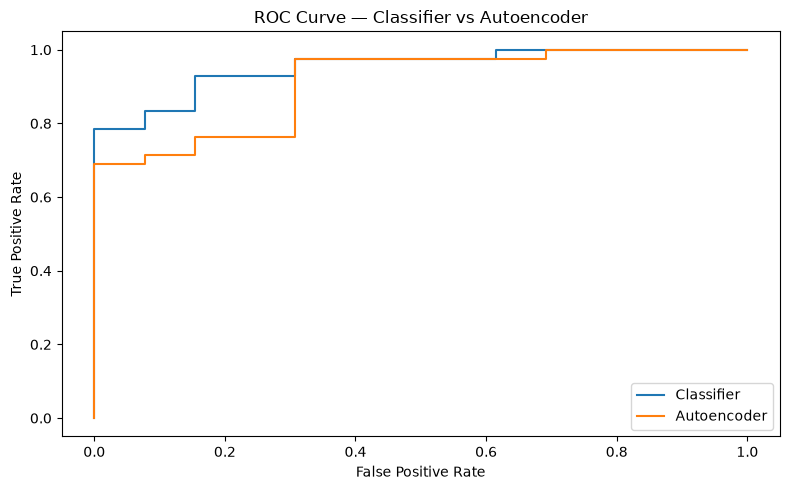

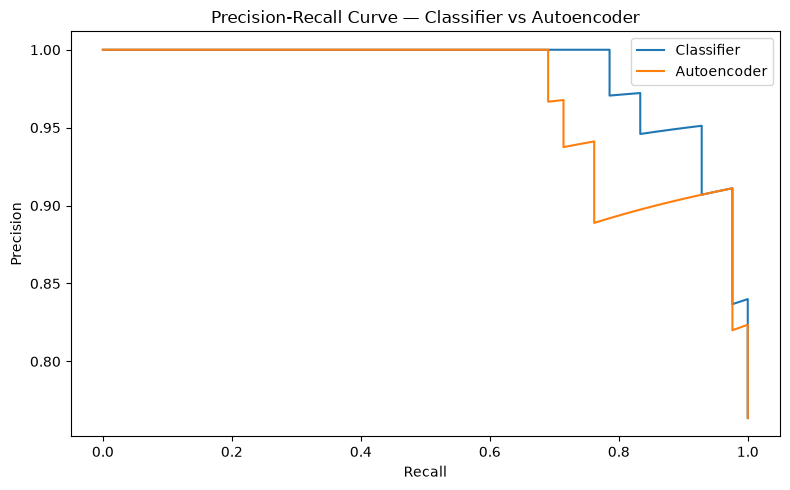

In [4]:
# recompute test-set scores for the most recent classifier and autoencoder
from src.models.classifier import DefectClassifier
from src.models.autoencoder import ConvAutoencoder, reconstruction_error_per_image

device=get_device(True)
#load checkpoints
classifier_checkpoint=torch.load(
    "../models/classifier/best_model.pt",
    map_location=device,
    weights_only=False,
)
autoencoder_checkpoint=torch.load(
    "../models/autoencoder/best_model.pt",
    map_location=device,
    weights_only=False,
)

#classifier
classifier_cfg=classifier_checkpoint["config"]
classifier_cfg["data"]["root"]="../data/mvtec_ad"
classifier_model_cfg=classifier_cfg["model"]

classifier=DefectClassifier(
    architecture=classifier_model_cfg["architecture"],
    pretrained=False,
    num_classes=classifier_model_cfg["num_classes"],
    dropout=classifier_model_cfg["dropout"],
    finetune_mode=classifier_model_cfg["finetune_mode"],
    unfrozen_layers=classifier_model_cfg.get("unfrozen_layers", []),
).to(device)
classifier.load_state_dict(classifier_checkpoint["model_state_dict"])
classifier.eval()
_, _, classifier_test_loader = build_classifier_dataloaders(classifier_cfg)
classifier_labels=[]
classifier_scores=[]
with torch.no_grad():
    for images, labels, _ in classifier_test_loader:
        logits=classifier(images.to(device))
        scores=torch.softmax(logits, dim=1)[:, 1]
        classifier_labels.extend(labels.tolist())
        classifier_scores.extend(scores.cpu().tolist())

#autoencoder
ae_cfg=autoencoder_checkpoint["config"]
ae_cfg["data"]["root"]="../data/mvtec_ad"
ae_model_cfg=ae_cfg["model"]
autoencoder=ConvAutoencoder(
    image_size=ae_cfg["data"]["image_size"],
    latent_dim=ae_model_cfg["latent_dim"],
    base_channels=ae_model_cfg["base_channels"],
    num_downsample_blocks=ae_model_cfg["num_downsample_blocks"],
).to(device)
autoencoder.load_state_dict(autoencoder_checkpoint["model_state_dict"])
autoencoder.eval()
_, _, _, ae_test_loader=build_ae_dataloaders(ae_cfg)
ae_labels, ae_scores=compute_scores(
    autoencoder,
    ae_test_loader,
    device,
)

#convert classifier results to numpy arrays
classifier_labels=np.array(classifier_labels)
classifier_scores=np.array(classifier_scores)
print(f"Classifier test samples: {len(classifier_labels)}")
print(f"Autoencoder test samples: {len(ae_labels)}")

#ROC curves
fpr_classifier, tpr_classifier, _ = roc_curve_points(
    classifier_labels,
    classifier_scores,
)
fpr_ae, tpr_ae, _ = roc_curve_points(
    ae_labels,
    ae_scores,
)
plt.figure(figsize=(8, 5))
plt.plot(
    fpr_classifier,
    tpr_classifier,
    label="Classifier",
)
plt.plot(
    fpr_ae,
    tpr_ae,
    label="Autoencoder",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Classifier vs Autoencoder")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../results/plots/roc_comparison.png",
    dpi=120,
)
plt.show()

# Precision-Recall curves
precision_classifier, recall_classifier, _ = pr_curve_points(
    classifier_labels,
    classifier_scores,
)
precision_ae, recall_ae, _ = pr_curve_points(
    ae_labels,
    ae_scores,
)
plt.figure(figsize=(8, 5))
plt.plot(
    recall_classifier,
    precision_classifier,
    label="Classifier",
)
plt.plot(
    recall_ae,
    precision_ae,
    label="Autoencoder",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Classifier vs Autoencoder")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../results/plots/pr_comparison.png",
    dpi=120,
)
plt.show()

## 3. Ablation comparison

Once multiple experiment JSONs exist (e.g. `classifier_resnet18_frozen`,
`classifier_resnet18_partial`, `classifier_resnet18_full` from re-running
`configs/classifier.yaml` with different `model.finetune_mode` values), plot
them side by side here.

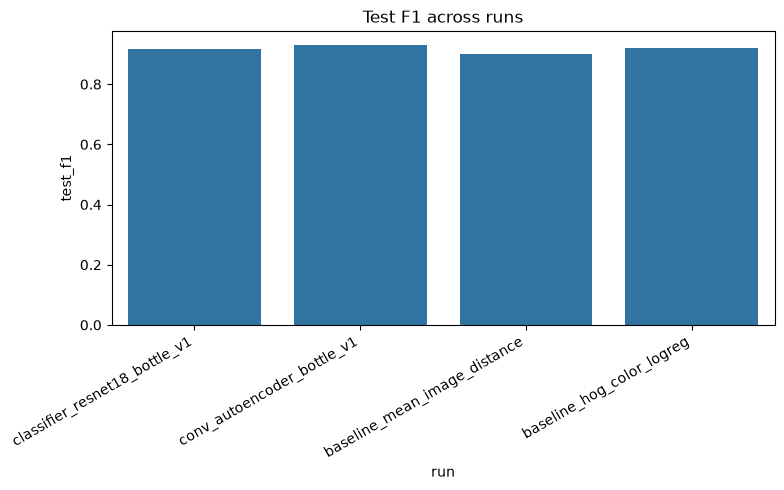

In [5]:
if len(df) > 1:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df, x='run', y='test_f1', ax=ax)
    ax.set_title('Test F1 across runs')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../results/plots/ablation_comparison.png', dpi=120)
    plt.show()
else:
    print('Need 2+ logged runs to compare — run more experiments first.')

## 4. Error analysis

For each model, identify: false positives (normal flagged defective),
false negatives (defective flagged normal), and the lowest-confidence
correct predictions. Visualize each with its heatmap/Grad-CAM to reason
about *why* the model likely failed (see README "Error Analysis").

In [6]:
from src.data.dataset import build_samples
from src.evaluation.error_analysis import(
    analyze_autoencoder_errors, analyze_classifier_errors,
    summarize_defect_area_vs_failure,
)
from src.inference import load_autoencoder, load_classifier
from src.utils import get_device

device=get_device(prefer_cuda=True)
classifier, clf_cfg=load_classifier('../models/classifier/best_model.pt', device)
autoencoder, ae_cfg=load_autoencoder('../models/autoencoder/best_model.pt', device)

test_samples=build_samples(
    '../data/mvtec_ad', 'bottle', 'labeled_test',
    seed=clf_cfg['experiment']['seed'], val_fraction=clf_cfg['data']['val_fraction'],
)

clf_results=analyze_classifier_errors(
    classifier, clf_cfg, device, test_samples, output_dir='../results/examples/classifier'
)
print('Classifier error counts:', clf_results['counts'])
print('Classifier defect-area correlation:', summarize_defect_area_vs_failure(clf_results['records']))

Classifier error counts: {'false_positive': 4, 'false_negative': 3, 'low_margin_correct': 4}
Classifier defect-area correlation: {'n_false_negatives_with_mask': 3, 'n_true_positives_with_mask': 39, 'mean_defect_area_fraction_false_negatives': 0.026798353909465018, 'mean_defect_area_fraction_true_positives': 0.08248803418803419, 'difference': 0.05568968027856917}


In [7]:
#pull the autoencoder's selected threshold from its logged experiment
from src.evaluation.experiment_log import load_all_experiments

ae_records=[r for r in load_all_experiments('../results/experiments') if 'autoencoder' in r['experiment_name']]
threshold=ae_records[-1]['metrics']['selected_threshold']
print('Using threshold:', threshold)

ae_results=analyze_autoencoder_errors(
    autoencoder, ae_cfg, device, test_samples, threshold, output_dir='../results/examples/autoencoder'
)
print('Autoencoder error counts:', ae_results['counts'])
print('Autoencoder defect-area correlation:', summarize_defect_area_vs_failure(ae_results['records']))

Using threshold: 0.0017037095967680216
Autoencoder error counts: {'false_positive': 4, 'false_negative': 2, 'low_margin_correct': 10}
Autoencoder defect-area correlation: {'n_false_negatives_with_mask': 2, 'n_true_positives_with_mask': 40, 'mean_defect_area_fraction_false_negatives': 0.0179358024691358, 'mean_defect_area_fraction_true_positives': 0.08153891975308641, 'difference': 0.06360311728395061}


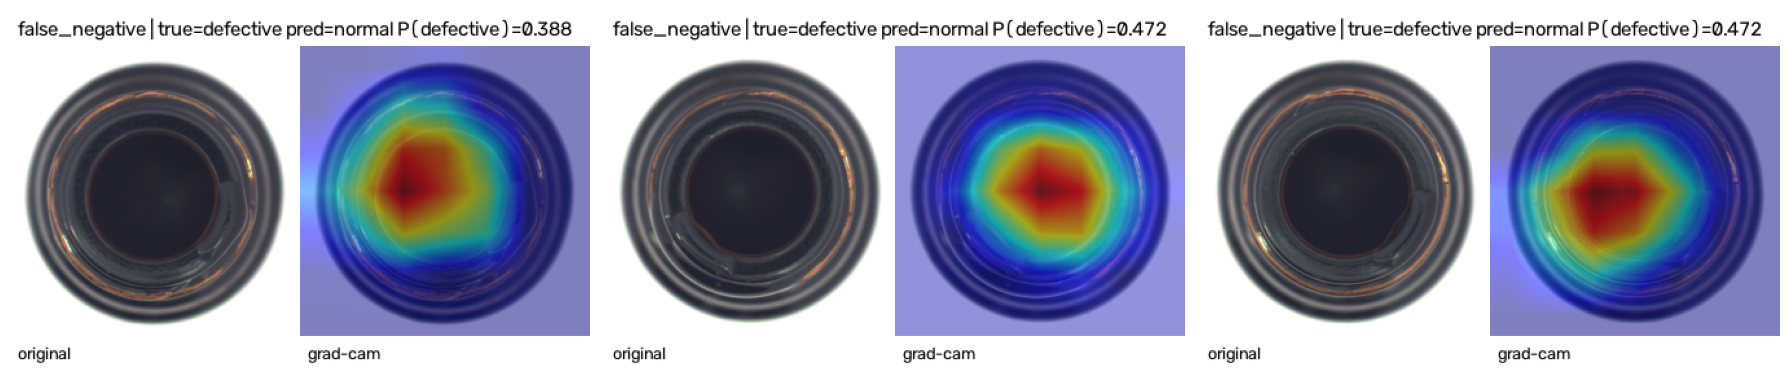

In [8]:
#visually inspect the saved composite images for the worst failures
import matplotlib.pyplot as plt
from PIL import Image as PILImage

fn_records=[r for r in clf_results['records'] if r['error_type'] == 'false_negative']
n_show=min(3, len(fn_records))
if n_show:
    fig, axes=plt.subplots(1, n_show, figsize=(6 * n_show, 5))
    axes=[axes] if n_show==1 else axes
    for ax, r in zip(axes, fn_records[:n_show]):
        ax.imshow(PILImage.open(r['saved_visualization_path']))
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No classifier false negatives to show.')